In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8]],dtype = float)
y = np.array([1,4,9,16,25,36,49,64], dtype = float)
print(X)

[[1.]
 [2.]
 [3.]
 [4.]
 [5.]
 [6.]
 [7.]
 [8.]]


In [3]:
X_b = np.c_[np.ones((X.shape[0],1)),X]
print(X_b)

[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]
 [1. 8.]]


In [5]:
def sgd_ultimate_w(X , y , learning_rate = 0.01 , n_epochs = 100):
    m = len(y)
    w = np.array([[0.0],[0.0]])
    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = 2 * xi.T.dot(xi.dot(w) - yi)
            w = w - learning_rate * gradients
    return w

ultimate_w = sgd_ultimate_w(X_b,y)
print(ultimate_w)

[[-15.06180049]
 [  8.94755691]]


In [9]:
def sgd_averaged_w(X , y , learning_rate = 0.01 , n_epochs = 100):
    m = len(y)
    w = np.array([[0.0],[0.0]])
    w_avg = np.zeros((2,1))

    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = 2 * xi.T.dot(xi.dot(w) - yi)
            w = w - learning_rate * gradients
        w_avg = (w_avg * epoch + w) / (epoch + 1)
    return w_avg

w_avg = sgd_averaged_w(X_b,y)

print(w_avg)

[[-10.45514004]
 [  8.12109141]]


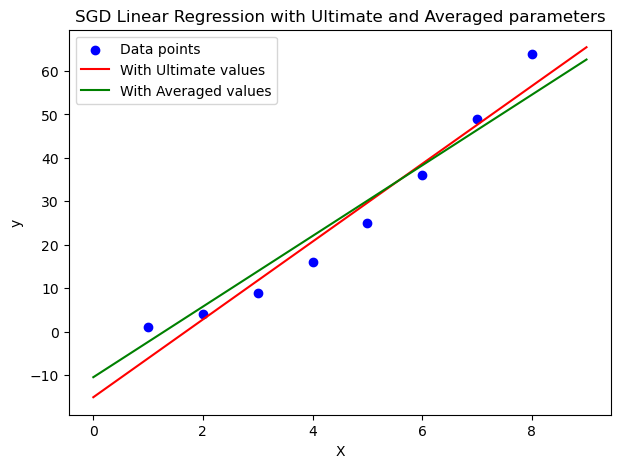

In [12]:
# -------- Plotting Section --------
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', label='Data points')

# Line with ultimate parameters
X_line = np.linspace(0, 9, 100)
y_ultimate = ultimate_w[0,0] + ultimate_w[1,0] * X_line
plt.plot(X_line, y_ultimate, color='red', label='With Ultimate values')

# Line with averaged parameters
y_avg = w_avg[0,0] + w_avg[1,0] * X_line
plt.plot(X_line, y_avg, color='green', label='With Averaged values')

plt.title("SGD Linear Regression with Ultimate and Averaged parameters")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()